**Name:** Francisco Morales Figueroa
**U. Galway ID:** 25247209

**Name:** Julien Jessmon 
**U. Galway ID:** 25239966

In [1]:
%pip install matplotlib numpy scikit-learn pandas --quiet

In [2]:
# Package imports
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import numpy as np

# Task 1 Implement Logistic Regression

Requirements
- Neural Network Logistic regression
- Handle different number of input features
- Handle different input training samples

In [3]:
# Prediction function
def predict(Xi, W, b):
    """ This function computes the predicted probabilities for a single input 
    sample Xi using the parameters W and b. It applies sigmoid acivation function.
    """
    # Linear transformation
    z = np.dot(Xi, W) + b
    # Sigmoid activation function
    y_hat = 1 / (1 + np.exp(-z))
    return y_hat

In [4]:
# Stochastic Gradient Descent function
def stochastic_gradient_descent(X, y, W, b, alpha=0.01, max_iters=1000, threshold=1e-4):
    """ This function performs stochastic gradient descent to optimize the parameters W and b for a single neuron.
    It follows the lecture pseudo code with some printings to monitor the cost function and its convergence.
    """
    # This version does not have loops on backpropagation because it is for just one neuron
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0

    while not stopping:
        # Randomly select one data point #Sample size = 1        
        i_random = np.random.randint(0, high=N)
        y_hat = predict(X[i_random], W, b)
        # Compute cost function for the selected data point
        J_current = -(y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))[0]
        error = y_hat - y[i_random]
        
        # This backpropagation is naive because it is for just one neuron.
        delta_W = error * X[i_random]
        delta_b = error
        
        # Update parameters with learning rate alpha
        W -= alpha * delta_W
        b -= alpha * delta_b

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
            print("Stopping by reaching maximum iterations:", max_iters)
        # Check cost function every N iterations--1 epoch
        if iteration % N == 0:
            J_avg = J_running / N
            if iteration % (50*N) == 0:
                print("Epoch:", int(iteration/N), "   Cost:", round(J_avg,6), 
                      " Previous Cost:", round(J_running_prev,6),
                      " Difference:", round(abs(J_avg - J_running_prev),6)
                      )
            # Check for convergence using the difference in average cost over epoch because it was more stable than comparing the sum
            if abs(J_avg - J_running_prev) < threshold:
                stopping = True
                print("Stopping by convergence at epoch:", int(iteration/N))
                print("Difference in cost function:", abs(J_avg - J_running_prev))
                
            J_running_prev = J_avg
            J_running = 0
        
    return W, b

# Task 2 Implement Logistic Regression

Requirements
- Read both files
- Split train(70), test(15), validation(15)
- Train logistic regressor and check performance
- Scatter plot of results

In [5]:
# Reading data function
def read_data(file_path):
    df = pd.read_csv(file_path)
    y = df['Class'].values   # Labels
    X = df.drop('Class', axis=1).values  # Features
    return X, y

In [6]:
def split_data(X, y, train_ratio=0.7, test_ratio=0.15, validation_ratio=0.15, random_state=1):
    """This function splits the data into training, testing, and validation sets based on the specified proortion.
    It uses the train_test_split function twice from scikit-learn to perform the splits into 3 sets."""
    # https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    X_train, X_test_pre, y_train, y_test_pre = sklearn.model_selection.train_test_split(
    X, y, train_size=train_ratio, random_state=random_state)
    
    X_test, X_val, y_test, y_val = sklearn.model_selection.train_test_split(
    X_test_pre, y_test_pre, train_size=test_ratio/(test_ratio + validation_ratio), random_state=random_state)
    
    return X_train, y_train, X_test, y_test, X_val, y_val

## Blobs 600 dataset

In [7]:
file_path = 'Dataset/blobs600.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y_train, W, b, alpha=1e-3, max_iters=100000, threshold=1e-4)

Epoch: 50    Cost: 0.034931  Previous Cost: 0.032443  Difference: 0.002488
Epoch: 100    Cost: 0.028842  Previous Cost: 0.024063  Difference: 0.004779
Stopping by convergence at epoch: 135
Difference in cost function: 7.126158901130802e-05


In [8]:
# Decision boundary to classify the predicted probability into binary classes
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

# Calculate accuracy for each set using np.mean
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", round(accuracy_train*100, 3), "%")
print("Test Accuracy:", round(accuracy_test*100, 3), "%")
print("Validation Accuracy:", round(accuracy_val*100, 3), "%")

Train Accuracy: 99.762 %
Test Accuracy: 98.889 %
Validation Accuracy: 98.889 %


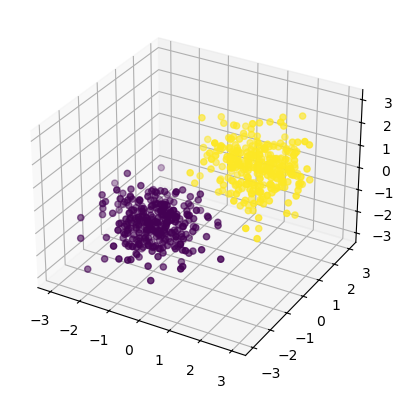

In [9]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_all[:, 0], X_all[:, 1], X_all[:, 2], c=y_pred_all)

Accuracy for blobs dataset is high since it was linearly separable.  
It reaches convergence after **135 epochs** with a **learning rate = 1e-3** and a **treshold = 1e-4**  
Plotting the results was very helpful to understand the dataset and its attibutes 

## Circles 500 dataset

In [10]:
file_path = 'Dataset/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y, W, b, alpha=1e-4, max_iters=100000, threshold=1e-6)

Epoch: 50    Cost: 0.691728  Previous Cost: 0.691519  Difference: 0.000209
Epoch: 100    Cost: 0.692641  Previous Cost: 0.689862  Difference: 0.002779
Epoch: 150    Cost: 0.68902  Previous Cost: 0.687235  Difference: 0.001785
Epoch: 200    Cost: 0.689066  Previous Cost: 0.6859  Difference: 0.003166
Epoch: 250    Cost: 0.687737  Previous Cost: 0.689558  Difference: 0.001821
Stopping by reaching maximum iterations: 100000


In [11]:
# Decision boundary to classify the predicted probability into binary classes
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

# Calculate accuracy for each set using np.mean
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", round(accuracy_train*100, 3), "%")
print("Test Accuracy:", round(accuracy_test*100, 3), "%")
print("Validation Accuracy:", round(accuracy_val*100, 3), "%")

Train Accuracy: 48.286 %
Test Accuracy: 54.667 %
Validation Accuracy: 48.0 %


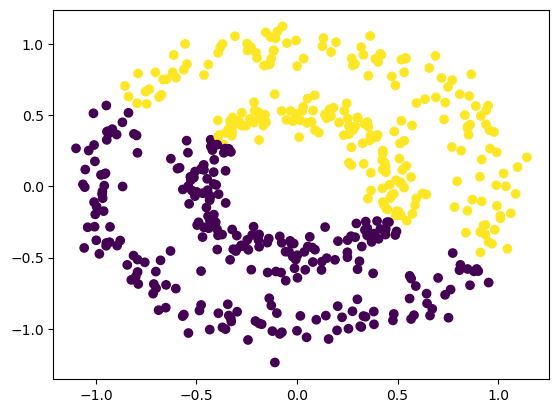

In [12]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

Accuracy for circles dataset is low and basically as good as a random choice.  
This is because it is no linearly separable and a simple logistic regression cannot approximate to a more complex function.  
The plot shows that the neuron trained a linear functinon

# Task 3: Implement and Test a Shallow Neural Network

Requirements
- 1 hidden layer
- 1 output node
- Support different number of inputs
- Support different number of nodes in the hidden layer

Test
- Test previous datasets with different number of nodes in the hidden layer
- Measure performance

In [13]:
def parameter_initialization(X, neurons_hidden_layer):
    """This function initializes parameters (W,b) for a neural network with one hidden layer. 
    neurons_hidden_layer is the number of neurons in the hidden layer.
    The weights and bias are initialized with small random values from a normal distribution. 
    z and a are initialized with zeros just to create the shape of them for the forward and backward propagation steps."""
    np.random.seed(3301)
    # Weight parameters
    W1 = np.random.normal(0,0.01,size=(neurons_hidden_layer,X.shape[1]))
    W2 = np.random.normal(0,0.01,size=(1,neurons_hidden_layer))
    W = [W1, W2]
    # Bias parameters
    b1 = np.random.normal(0,0.01,size=(neurons_hidden_layer))
    b2 = np.random.normal(0,0.01,size=(1))
    b = [b1, b2]
    
    # https://numpy.org/devdocs/reference/generated/numpy.zeros.html
    z1 = np.zeros(shape=(neurons_hidden_layer))
    z2 = np.zeros(shape=(1))
    z = [z1, z2]
    a0 = np.zeros(shape=(X.shape[1]))
    a1 = np.zeros(shape=(neurons_hidden_layer))
    a2 = np.zeros(shape=(1))
    a = [a0, a1, a2]

    return W, b, z, a

In [14]:
# Forward propagation function
def forward_propagation(Xi, W, b, z, a):
   """Forward propagation function for a single input Xi"""
   # X[observation][feature] 
   # W[layer][destination_node][source_node]
   # b[layer][destination_node]
   # z[layer][destination_node]
   # a[layer][destination_node]
   a[0] = Xi # Inputs are activations of layer 0
   for layer in range(1, len(W)+1):
      for destination_node in range(1, len(z[layer-1])+1):
         # Linear transformation 
         z[layer-1][destination_node-1] = np.dot(a[layer-1], W[layer-1][destination_node-1]) + b[layer-1][destination_node-1]
         # Activation function (Using logistic function)
         a[layer][destination_node-1] = 1 / (1 + np.exp(-z[layer-1][destination_node-1]))

   y_hat = a[layer][destination_node-1] # Output of the last layer is the prediction
   return y_hat, a, z

In [15]:
# Return only the prediction
def predict_t3(X, W, b, z, a):
    """Prepares forward propagation function for multiple input samples X"""
    y_hats = np.zeros(shape=(X.shape[0]))
    for i, Xi in enumerate(X):
        y_hat, a, z = forward_propagation(Xi, W, b, z, a)
        y_hats[i] = y_hat
    return y_hats

In [16]:
# Backpropagation and gradient descent function
def gradient_descent_t3(X, y, W, b, a, z, alpha=0.01, max_iters=1000, threshold=1e-4, neurons_hidden_layer=5):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    # Initialize delta parameters for gradient descent
    delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
    delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
    delta_W = [delta_W1, delta_W2]

    delta_b1 = np.zeros(shape=(neurons_hidden_layer))
    delta_b2 = np.zeros(shape=(1))
    delta_b = [delta_b1, delta_b2]

    delta_z1 = np.zeros(shape=(neurons_hidden_layer))
    delta_z2 = np.zeros(shape=(1))
    delta_z = [delta_z1, delta_z2]
    
    while not stopping:
        # Randomly select one data point #Sample size = 1       
        i_random = np.random.randint(0, high=N)
        y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        
        # Backpropagation step
        error = y_hat - y[i_random] 
        for layer in range(len(W), 0, -1):
            # Output layer gradients
            if layer == len(W):
                delta_z[layer-1] = error
                # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                delta_W[layer-1] = error * a[layer-1].reshape(1, -1)
                delta_b[layer-1] = error
            # Hidden layer gradients
            else:
                # Derivative of logistic is f(z) * (1 - f(z)). 
                # Therefore, we can use the activation layer instead of calculating the logistic function again
                delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * W[layer].reshape(-1)
                # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
                delta_b[layer-1] = delta_z[layer-1]

        # Update parameters step
        for layer in range(1, len(W)+1):
            W[layer-1] -= alpha * delta_W[layer-1]
            b[layer-1] -= alpha * delta_b[layer-1]
        
        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
            print("Stopping by reaching maximum iterations:", max_iters)
        if iteration % N == 0: # 1 Epoch finished
            J_avg = J_running / N
            if iteration % (2000*N) == 0:
                print("Epoch:", int(iteration/N), "   Cost:", round(J_avg,6), 
                      " Previous Cost:", round(J_running_prev,6),
                      " Difference:", round(abs(J_avg - J_running_prev),6)
                      )
            if abs(J_avg - J_running_prev) < threshold:
                stopping = True
                print("Stopping by convergence at epoch:", int(iteration/N))
                print("Difference in cost function:", abs(J_avg - J_running_prev))
            J_running_prev = J_avg
            J_running = 0
              
    return W, b, a, z  

## Blobs 600 dataset

In [17]:
file_path = 'Dataset/blobs600.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 4
W, b, z, a = parameter_initialization(X, neurons_hidden_layer=neurons_hidden_layer)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained, a_trained, z_trained = gradient_descent_t3(X_train, y_train, W, b, a, z, 
                                                                 alpha=1e-3, max_iters=800000, 
                                                                 threshold=1e-5, 
                                                                 neurons_hidden_layer=neurons_hidden_layer)


Stopping by convergence at epoch: 1393
Difference in cost function: 8.380746544547207e-06


In [18]:
# Decision boundary to classify the predicted probability into binary classes
treshold = 0.5

y_hat_train = predict_t3(X_train, W_trained, b_trained, z_trained, a_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict_t3(X_test, W_trained, b_trained, z_trained, a_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict_t3(X_val, W_trained, b_trained, z_trained, a_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

# Calculate accuracy for each set using np.mean
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", round(accuracy_train*100, 3), "%")
print("Test Accuracy:", round(accuracy_test*100, 3), "%")
print("Validation Accuracy:", round(accuracy_val*100, 3), "%")

Train Accuracy: 99.762 %
Test Accuracy: 98.889 %
Validation Accuracy: 100.0 %


## Circles 500 dataset

In [19]:
file_path = 'Dataset/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 5
W, b, z, a = parameter_initialization(X, neurons_hidden_layer=neurons_hidden_layer)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained, a_trained, z_trained = gradient_descent_t3(X_train, y_train, W, b, a, z, 
                                                                 alpha=1e-2, max_iters=10000000, 
                                                                 threshold=1e-6, 
                                                                 neurons_hidden_layer=neurons_hidden_layer)

Epoch: 2000    Cost: 0.108895  Previous Cost: 0.111182  Difference: 0.002287
Epoch: 4000    Cost: 0.028379  Previous Cost: 0.035217  Difference: 0.006838
Epoch: 6000    Cost: 0.014489  Previous Cost: 0.01403  Difference: 0.000459
Stopping by convergence at epoch: 6902
Difference in cost function: 9.783105273560022e-07


In [20]:
# Decision boundary to classify the predicted probability into binary classes
treshold = 0.5

y_hat_train = predict_t3(X_train, W_trained, b_trained, z_trained, a_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict_t3(X_test, W_trained, b_trained, z_trained, a_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict_t3(X_val, W_trained, b_trained, z_trained, a_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

# Calculate accuracy for each set using np.mean
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", round(accuracy_train*100, 3), "%")
print("Test Accuracy:", round(accuracy_test*100, 3), "%")
print("Validation Accuracy:", round(accuracy_val*100, 3), "%")

Train Accuracy: 100.0 %
Test Accuracy: 100.0 %
Validation Accuracy: 100.0 %


The neural network now is able to handle linear and non linear data performing better in the circle dataset.    
If there are few neurons in the hidden layer it is not able to represent the function so it has poor performance.
If there are many neurons the training and convergence becomes slower  

Best configuration in our case was:  
**learning rate = 1e-2**  
**neurons in hidden layer >= 4**  
**treshold = 1e-6**

# Task 4: Tackle a Challenging Task

Requirements
- Read image dataset
- Filter two letters (C,F)
- Reshape images (flatten it)
- 1 hidden layer
- 1 output node
- Support different number of inputs
- Support different number of nodes in the hidden layer


Test
- Check accuracy
- Plot training curve

In [21]:
# Backpropagation and gradient descent function
def gradient_descent_t4(X, y, W, b, a, z, alpha=0.01, max_iters=1000, threshold=1e-4, neurons_hidden_layer=5):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    # Initialize delta parameters for gradient descent
    delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
    delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
    delta_W = [delta_W1, delta_W2]

    delta_b1 = np.zeros(shape=(neurons_hidden_layer))
    delta_b2 = np.zeros(shape=(1))
    delta_b = [delta_b1, delta_b2]

    delta_z1 = np.zeros(shape=(neurons_hidden_layer))
    delta_z2 = np.zeros(shape=(1))
    delta_z = [delta_z1, delta_z2]
    
    J_diff_array = []
    
    while not stopping:
        # Randomly select one data point #Sample size = 1       
        i_random = np.random.randint(0, high=N)
        y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        
        # Backpropagation step
        error = y_hat - y[i_random] 
        for layer in range(len(W), 0, -1):
            # Output layer gradients
            if layer == len(W):
                delta_z[layer-1] = error
                # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                delta_W[layer-1] = error * a[layer-1].reshape(1, -1)
                delta_b[layer-1] = error
            # Hidden layer gradients
            else:
                # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
                delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * W[layer].reshape(-1)
                # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
                delta_b[layer-1] = delta_z[layer-1]

        # Update parameters step
        for layer in range(1, len(W)+1):
            W[layer-1] -= alpha * delta_W[layer-1]
            b[layer-1] -= alpha * delta_b[layer-1]
        
        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
            print("Stopping by reaching maximum iterations:", max_iters)
            print("Difference in cost function:", abs(J_running / N - J_running_prev))
        if iteration % N == 0: # 1 Epoch finished
            J_avg = J_running / N
            if iteration % (2000*N) == 0:
                print("Epoch:", int(iteration/N), "   Cost:", round(J_avg,6), 
                      " Previous Cost:", round(J_running_prev,6),
                      " Difference:", round(abs(J_avg - J_running_prev),6)
                      )
            J_diff_array.append(abs(J_avg - J_running_prev))
            if abs(J_avg - J_running_prev) < threshold:
                stopping = True
                print("Stopping by convergence at epoch:", int(iteration/N))
                print("Difference in cost function:", abs(J_avg - J_running_prev))
            J_running_prev = J_avg
            J_running = 0   
         
    plt.plot(J_diff_array, label='Difference in Cost')
    plt.xlabel('Epochs (Every N iterations)')
    plt.ylabel('Cost')
    plt.title('Cost Function over Epochs')
    plt.legend()
    plt.show()
                                 
    return W, b, a, z  

In [22]:
# Reading images
data = np.load("Dataset/emnist_letters_85800.npz")
x_data = data["x"]
y_data = data["y"]

# Extract just two classes from the dataset
c1 = 3   # C
c2 = 6  # F

mask = (y_data == c1) | (y_data == c2)
x_binary = x_data[mask]
y_binary = y_data[mask]
# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [23]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")
# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"For a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")
# Check the shape of the two classes
print(f"Shape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).
For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).
Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


Stopping by convergence at epoch: 693
Difference in cost function: 3.8377293383549255e-07


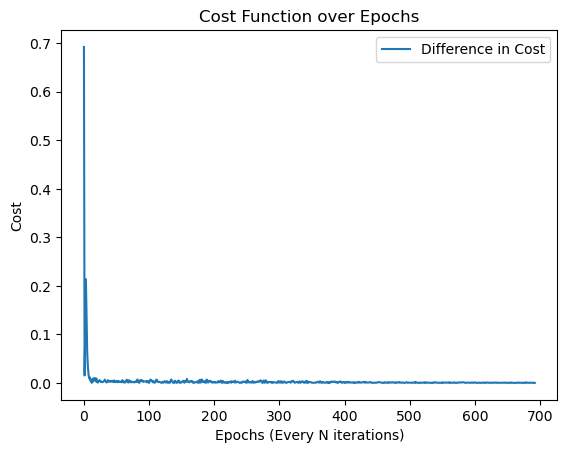

In [24]:
# Flatten the images
x_flat = x_binary.reshape(x_binary.shape[0], -1)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(x_flat, y_binary)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 8
W, b, z, a = parameter_initialization(x_flat, neurons_hidden_layer=neurons_hidden_layer)
# Training the model using Stochastic Gradient Descent
W_trained, b_trained, a_trained, z_trained = gradient_descent_t4(X=X_train, y=y_train, 
                                                                 W=W, b=b, a=a, z=z, 
                                                                 alpha=1e-3, max_iters=10000000, 
                                                                 threshold=1e-6, 
                                                                 neurons_hidden_layer=neurons_hidden_layer)


In [27]:
treshold = 0.5
y_hat_train= predict_t3(X_train, W_trained, b_trained, z_trained, a_trained) 
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict_t3(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict_t3(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", round(accuracy_train*100, 3), "%")
print("Test Accuracy:", round(accuracy_test*100, 3), "%")
print("Validation Accuracy:", round(accuracy_val*100, 3), "%")

Train Accuracy: 100.0 %
Test Accuracy: 99.091 %
Validation Accuracy: 98.788 %


The neural network is able to effectively classify the 2 letters.  
It could be because c and f have clear different contours that are easy to detect with a small network  
Good results (convergence) are find with:  
**learning rate = 1e-3**  
**treshold = 1e-6**  
**neurons in hidden layer >= 6**  

# Task 5: Deep Learning enhancements

Requirements
- Support any number of layers
- Suport any number of neurons in each layer
- Implement method to avoid overfitting


Test
- Test different layers and with or without overfitting method
- Check accuracy
- Plot training curve

In [30]:
# Reading images
# data = np.load("data/emnist_letters_85800.npz")
data = np.load("Dataset/emnist_letters_85800.npz")
x_data = data["x"]
y_data = data["y"]

# Extract just two classes from the dataset
c1 = 3   # C
c2 = 6  # F

mask = (y_data == c1) | (y_data == c2)
x_binary = x_data[mask]
y_binary = y_data[mask]
# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [31]:
# hidden_neurons_per_layer = [3,4,5,6,7,8,9,10]
# each position in the array is the hidden layer and the value is the number of neurons in that layer
def robust_parameter_initialization(X, hidden_neurons_per_layer): #3,4,5,6,7,8,9,10]
    W = []
    b = []
    z = []
    a = []
    np.random.seed(3301)

    a.append(np.zeros(shape=(X.shape[1]))) # a0
    for i, num_neurons in enumerate(hidden_neurons_per_layer):
        if i == 0:
            prev_layer_neurons = X.shape[1]
        else:
            prev_layer_neurons = hidden_neurons_per_layer[i-1]
        # Create weight matrix for the current layer
        W_aux = np.random.normal(0,0.01,size=(num_neurons,prev_layer_neurons))
        W.append(W_aux)
        # Create bias vector for the current layer
        b_aux = np.random.normal(0,0.01,size=(num_neurons))
        b.append(b_aux)
        # Create z vector 
        z_aux = np.zeros(shape=(num_neurons))
        z.append(z_aux)
        # Create activation vector a
        a_aux = np.zeros(shape=(num_neurons))
        a.append(a_aux)
        # print(i, num_neurons)

    W_aux_ll = np.random.normal(0,0.01,size=(1,num_neurons))
    W.append(W_aux_ll)
    b_aux_ll = np.random.normal(0,0.01,size=(1))
    b.append(b_aux_ll)
    z_aux_ll = np.zeros(shape=(1))
    z.append(z_aux_ll)
    a_aux_ll = np.zeros(shape=(1))
    a.append(a_aux_ll)
    
    return W, b, z, a

In [32]:
# Forward propagation function
def forward_prop(Xi, W, b, z, a):
   a[0] = Xi # Inputs are activations of layer 0
   for layer in range(len(W)):
       # Linear transformation 
       z[layer] = np.dot(W[layer], a[layer]) + b[layer]
       # Activation function (Using logistic function)
       a[layer + 1] = 1 / (1 + np.exp(-z[layer]))

   y_hat = a[len(a) - 1][0] # Output of the last layer is the prediction
   return y_hat, a, z

In [33]:
def predict_DNN(X, W, b, z, a):
    y_hat_arr = np.zeros(shape=(X.shape[0]))
    for i, Xi in enumerate(X):
        y_hat, a, z = forward_prop(Xi, W, b, z, a)
        y_hat_arr[i] = y_hat
    return y_hat_arr

In [34]:
def gradient_descent_l2(X, y, W, b, a, z, alpha, max_iters, threshold, penlambda, hidden_neurons_per_layer):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    l2 = 0
    J_diff_array = []

    delta_W = []
    delta_b = []
    delta_z = []
    
    # Initialize delta parameters for hidden layers
    for i, num_neurons in enumerate(hidden_neurons_per_layer):
        if i == 0:
            prev_layer_neuron = X.shape[1]
        else:
            prev_layer_neuron = hidden_neurons_per_layer[i-1]

        delta_W.append(np.zeros(shape=(num_neurons, prev_layer_neuron)))
        delta_b.append(np.zeros(shape=(num_neurons)))
        delta_z.append(np.zeros(shape=(num_neurons)))

    # Initialize delta for output layer
    delta_W.append(np.zeros(shape=(1, hidden_neurons_per_layer[-1])))
    delta_b.append(np.zeros(shape=(1)))
    delta_z.append(np.zeros(shape=(1)))

    iteration = 0
    
    while not stopping and iteration < max_iters:
        i_random = np.random.randint(0, high=N)

        a_copy = [arr.copy() for arr in a]
        z_copy = [arr.copy() for arr in z]
        
        y_hat, a_copy, z_copy = forward_prop(X[i_random], W, b, z_copy, a_copy)

        l2 = 0
        for w_arr in W:
            l2 += np.sum(w_arr ** 2)
        
        J_current = (- (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))) + ((penlambda / (2 * N)) * l2)

        # Backpropagation step
        error = y_hat - y[i_random]

        delta_z_copy = [np.zeros_like(dz) for dz in z_copy]
        delta_W_copy = [np.zeros_like(dw) for dw in W]
        delta_b_copy = [np.zeros_like(db) for db in b]

        
        for layer in range(len(W)-1, -1, -1):
            # Output layer gradients
            if layer == len(W)-1:
                delta_z_copy[layer] = error
                # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                delta_W_copy[layer] = error * a_copy[layer].reshape(1, -1) + ((penlambda / N) * W[layer])
                delta_b_copy[layer] = error

            # Hidden layer gradients
            else:
                # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
                p1 = a_copy[layer+1] * (1 - a_copy[layer+1])
                p2 = np.dot(W[layer+1].T, delta_z_copy[layer+1]).flatten()
                delta_z_copy[layer] = p1 * p2
                # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                delta_W_copy[layer] = np.outer(delta_z_copy[layer], a_copy[layer]) + ((penlambda / N) * W[layer])
                delta_b_copy[layer] = delta_z_copy[layer]

                # delta_W_copy[layer] = delta_W_copy[layer] + ((penlambda / N) * W[layer])

        # Update parameters step
        for layer in range(len(W)):
            W[layer] -= alpha * delta_W_copy[layer]
            b[layer] -= alpha * delta_b_copy[layer]

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
            print("Stopping by reaching maximum iterations:", max_iters)
            print("Difference in cost function:", abs(J_running / N - J_running_prev))
        if iteration % N == 0: # 1 Epoch finished
            J_avg = J_running / N
            if iteration % (10*N) == 0:
                print("Epoch:", int(iteration/N), "   Cost:", round(J_avg,6), 
                      " Previous Cost:", round(J_running_prev,6),
                      " Difference:", round(abs(J_avg - J_running_prev),6)
                      )
            J_diff_array.append(abs(J_avg - J_running_prev))
            if abs(J_avg - J_running_prev) < threshold:
                stopping = True
                print("Stopping by convergence at epoch:", int(iteration/N))
                print("Difference in cost function:", abs(J_avg - J_running_prev))
            J_running_prev = J_avg
            J_running = 0

    plt.plot(J_diff_array, label='Difference in Cost')
    plt.xlabel('Epochs (Every N iterations)')
    plt.ylabel('Cost')
    plt.title('Cost Function over Epochs')
    plt.legend()
    plt.show()
    
    return W, b, a_copy, z_copy

Epoch: 10    Cost: 0.025109  Previous Cost: 0.016221  Difference: 0.008888
Epoch: 20    Cost: 0.046339  Previous Cost: 0.008129  Difference: 0.03821
Epoch: 30    Cost: 0.017057  Previous Cost: 0.013291  Difference: 0.003766
Epoch: 40    Cost: 0.002506  Previous Cost: 0.002526  Difference: 2e-05
Stopping by convergence at epoch: 40
Difference in cost function: 1.9877280302096813e-05


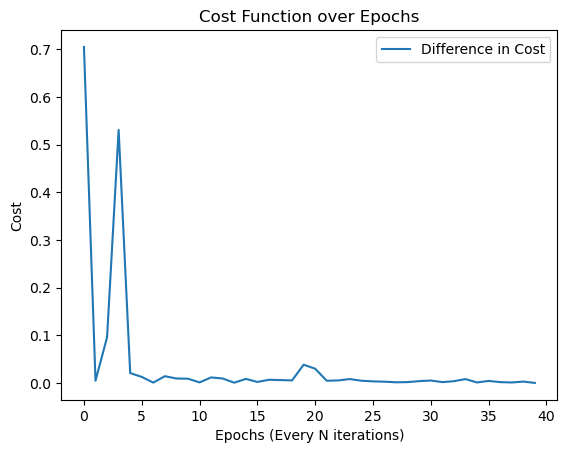

In [35]:
x_flat = x_binary.reshape(x_binary.shape[0], -1)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(x_flat, y_binary)
# Initialize weights and bias
np.random.seed(3301)
hidden_neurons_per_layer = [3,4,5]
W, b, z, a = robust_parameter_initialization(X_train, hidden_neurons_per_layer=hidden_neurons_per_layer)

W_trained, b_trained, a_trained, z_trained = gradient_descent_l2(X_train, y_train, W, b, a, z, alpha=1e-1, max_iters=1e6, threshold=1e-4, penlambda=1e-2, hidden_neurons_per_layer=hidden_neurons_per_layer)

In [36]:
treshold = 0.01
y_hat_train= predict_DNN(X_train, W_trained, b_trained, z_trained, a_trained) 
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict_DNN(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict_DNN(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)

In [37]:
# Calculate accuracy for each set using np.mean
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", round(accuracy_train*100, 3), "%")
print("Test Accuracy:", round(accuracy_test*100, 3), "%")
print("Validation Accuracy:", round(accuracy_val*100, 3), "%")

Train Accuracy: 99.199 %
Test Accuracy: 99.091 %
Validation Accuracy: 99.091 %
